In [40]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
%matplotlib inline
#from sklearn.externals.six import StringIO 
from six import StringIO
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
import seaborn as sns
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
from sklearn.metrics import recall_score

## Data

In [2]:
loan = pd.read_csv(os.path.abspath(os.path.join(os.getcwd() + '\\..\\data\\train_loanpred.csv')))
tree_loan = loan.loc[:, ~loan.columns.isin(["Loan_ID"])]
tree_loan.head(5)
print(tree_loan.shape)

(614, 12)


In [134]:
tree_loan.isnull().sum().sort_values(ascending=False)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [4]:
tree_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.00000,592.000000,600.00000,564.000000
mean,5403.459283,1621.24430,146.412162,342.00000,0.842199
std,6109.041673,2926.24876,85.587325,65.12041,0.364878
min,150.000000,0.00000,9.000000,12.00000,0.000000
25%,2877.500000,0.00000,100.000000,360.00000,1.000000
50%,3812.500000,1188.50000,128.000000,360.00000,1.000000
75%,5795.000000,2297.25000,168.000000,360.00000,1.000000
max,81000.000000,41667.00000,700.000000,480.00000,1.000000


In [5]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))
tree_loan['LoanAmount'] = imputer.transform(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))


C:\Users\nedwi\AppData\Local\Temp\ipykernel_7324\3530304682.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tree_loan['LoanAmount'] = imputer.transform(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))


In [6]:
imputer_clf = SimpleImputer(strategy='most_frequent')
cat_df = tree_loan.drop(columns=['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome', 'Loan_Status'], axis=1)
clf_imputer = imputer_clf.fit_transform(cat_df)
clf_imputer


array([['Male', 'No', '0', ..., 360.0, 1.0, 'Urban'],
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 'Rural'],
       ['Male', 'Yes', '0', ..., 360.0, 1.0, 'Urban'],
       ...,
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 'Urban'],
       ['Male', 'Yes', '2', ..., 360.0, 1.0, 'Urban'],
       ['Female', 'No', '0', ..., 360.0, 0.0, 'Semiurban']],
      shape=(614, 8), dtype=object)

In [12]:
tree_loan.loc[:, cat_df.columns] = clf_imputer

In [13]:
tree_loan.isnull().sum().sort_values(ascending=False)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
tree_loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0,141.000000,360.0,1.0,Urban,Y


In [10]:
tree_loan["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [15]:
X = tree_loan.iloc[:, :-1]
Y = tree_loan.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=22)

In [16]:
x_cat= pd.get_dummies(x_train[cat_df.columns], drop_first=True)
x_test_cat = pd.get_dummies(x_test[cat_df.columns], drop_first=True)
# Ensure that the test data has the same columns as the training data by adding missing columns
x_test_cat = x_test_cat.reindex(columns=x_cat.columns, fill_value=0)

print(x_cat.shape)
x_cat.head()

(429, 11)


,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
278,360.0,1.0,True,True,False,False,False,False,False,True,False
507,360.0,1.0,True,False,False,False,False,False,False,False,True
430,360.0,1.0,False,False,True,False,False,False,True,True,False
58,360.0,1.0,True,True,True,False,False,False,False,False,True
538,360.0,1.0,True,True,False,False,False,True,False,False,False


In [17]:
x_train.drop(columns=cat_df.columns, axis=1, inplace=True)
x_train = pd.concat([x_train, x_cat], axis=1)
x_train.shape

(429, 14)

In [18]:
x_train.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
278,14583,0,436.0,360.0,1.0,True,True,False,False,False,False,False,True,False
507,3583,0,96.0,360.0,1.0,True,False,False,False,False,False,False,False,True
430,8624,0,150.0,360.0,1.0,False,False,True,False,False,False,True,True,False
58,8080,2250,180.0,360.0,1.0,True,True,True,False,False,False,False,False,True
538,2917,536,66.0,360.0,1.0,True,True,False,False,False,True,False,False,False


# Single feature Tree

In [16]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, splitter='best', random_state=42)
clf.fit(x_train[["ApplicantIncome"]], y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


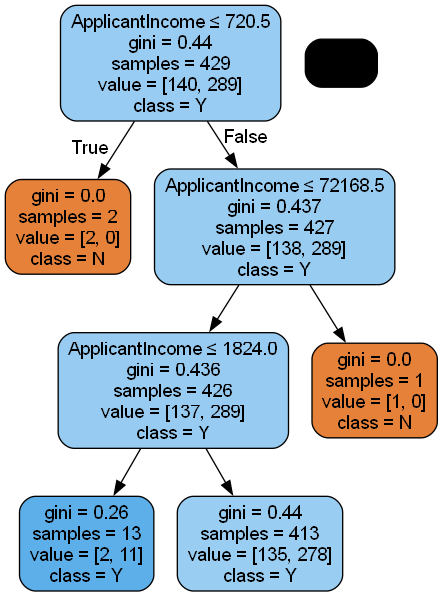

In [17]:
#features = x_cat.columns
features = ['ApplicantIncome']

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names = features ,class_names=['N','Y'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("loan_tree.png")
Image(graph.create_png())

## predict

In [24]:
x_test.drop(columns=cat_df.columns, axis=1, inplace=True)
x_test = pd.concat([x_test, x_test_cat], axis=1)
x_test.shape

(185, 14)

In [27]:
y_pred = clf.predict(x_test[["ApplicantIncome"]])
print("Predicted Results:\n", y_pred)


Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']


In [35]:
pd.DataFrame(y_pred).value_counts()

0
Y    182
N      3
Name: count, dtype: int64

In [29]:
predictions = clf.predict_proba(x_test[["ApplicantIncome"]])
predictions

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [30]:

recall_score(y_test,y_pred, average='macro') #weighted, micro, binary
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred)*100) 
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Test Classification Report :\n", classification_report(y_test, y_pred))

Test Accuracy Score :  70.27027027027027
Test Confusion Matrix :
 [[  0  52]
 [  3 130]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.00      0.00      0.00        52
           Y       0.71      0.98      0.83       133

    accuracy                           0.70       185
   macro avg       0.36      0.49      0.41       185
weighted avg       0.51      0.70      0.59       185



In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(predictions[:,0], bins=50, label="No" , alpha=0.5)
ax.hist(predictions[:,1], bins=50, label="Yes", color='r', alpha =0.5)
ax.legend()

[Text(0.5, 0.875, 'x[1] <= 0.5\ngini = 0.44\nsamples = 429\nvalue = [140, 289]'),
 Text(0.25, 0.625, 'x[0] <= 240.0\ngini = 0.17\nsamples = 64\nvalue = [58, 6]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[9] <= 0.5\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.0625, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.375, 'x[2] <= 0.5\ngini = 0.131\nsamples = 57\nvalue = [53, 4]'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.4375, 0.125, 'gini = 0.159\nsamples = 46\nvalue = [42, 4]'),
 Text(0.75, 0.625, 'x[3] <= 0.5\ngini = 0.348\nsamples = 365\nvalue = [82, 283]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 420.0\ngini = 0.432\nsamples = 117\nvalue = [37, 80]'),
 Text(0.5625, 0.125, 'gini = 0.414\nsamples = 113\nvalue = [33, 80]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.875, 0.375, 'x[9] <= 0.5\ngini = 0.2

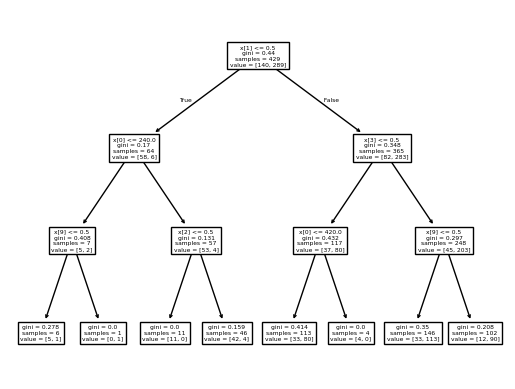

In [36]:
from sklearn import tree 
tree.plot_tree(clf.fit(x_cat, y_train)) 

In [ ]:
from sklearn.tree.export import export_text
text = export_text(clf, feature_names=x_cat.columns)

In [ ]:
import seaborn as sns
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix, annot=True)

## post pruning

{'ccp_alphas': array([0.00000000e+00, 2.37904934e-18, 3.56857401e-18, 3.56857401e-18,
       3.56857401e-18, 4.22576238e-18, 4.75809868e-18, 4.75809868e-18,
       6.33864357e-18, 8.64360486e-18, 9.98816562e-18, 1.09485662e-17,
       1.69030495e-17, 2.49800181e-17, 1.48957299e-03, 1.54320988e-03,
       1.54320988e-03, 1.57728707e-03, 1.57728707e-03, 1.60085379e-03,
       1.61812298e-03, 1.69515978e-03, 1.75746924e-03, 2.14899713e-03,
       2.16785382e-03, 2.26389672e-03, 2.33100233e-03, 2.33100233e-03,
       2.33100233e-03, 2.36394936e-03, 2.48461089e-03, 2.65565990e-03,
       2.75658438e-03, 2.78551532e-03, 2.78551532e-03, 2.97914598e-03,
       2.98862299e-03, 3.11249444e-03, 3.15457413e-03, 3.18515212e-03,
       3.22683127e-03, 3.24746038e-03, 3.46311260e-03, 3.77684054e-03,
       3.95290766e-03, 4.01386101e-03, 4.03842442e-03, 4.15620092e-03,
       4.20274457e-03, 4.20462509e-03, 4.22166479e-03, 4.50378302e-03,
       4.59432668e-03, 5.09333708e-03, 5.23174877e-03, 5.83182

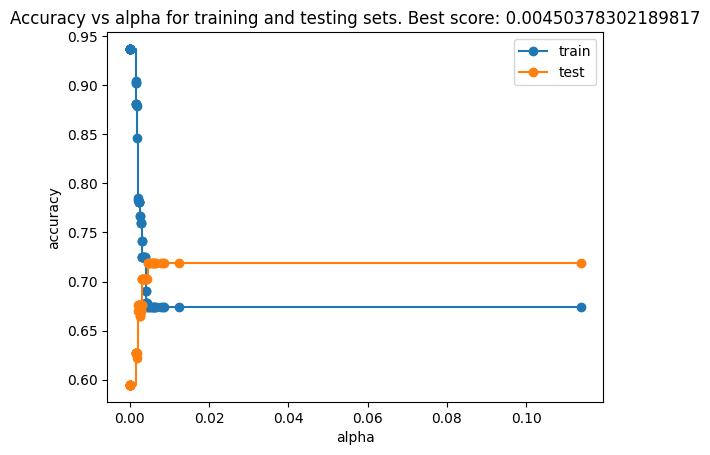

In [112]:
'''
DecisionTreeClassifier.cost_complexity_pruning_path returns the effective alphas and the corresponding total leaf impurities at each step of the 
pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.
'''
ccp_path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = ccp_path.ccp_alphas
impurities = ccp_path.impurities
print(ccp_path)


X = x_train[["ApplicantIncome"]]
X_t = x_test[["ApplicantIncome"]]
train_scores=[]
test_scores= []
trees = []
for ccp_alpha in ccp_alphas:
    clf=DecisionTreeClassifier(random_state=0,ccp_alpha=ccp_alpha)
    clf.fit(X,y_train)
    trees.append(clf)
    train_scores.append(clf.score(X, y_train))
    test_scores.append(clf.score(X_t, y_test))

best_alpha = ccp_alphas[np.argmax(test_scores)]
best_alpha

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy vs alpha for training and testing sets. Best score: {best_alpha}")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",drawstyle="steps-post")
ax.legend()
plt.show()

In [113]:
best_tree=DecisionTreeClassifier(random_state=0,ccp_alpha=best_alpha)
best_tree.fit(X,y_train)
print(best_tree.score(X, y_train))
best_tree.score(X_t, y_test)

0.6736596736596736


0.7189189189189189

In [114]:
result = pd.DataFrame(data=
             { 
    "ccp_alphas": ccp_path["ccp_alphas"],
    "impurities": ccp_path["impurities"],
    "train_scores": train_scores,
    "test_scores": test_scores
   })

result.iloc[np.argmax(result["test_scores"]), :]

ccp_alphas      0.004504
impurities      0.194764
train_scores    0.673660
test_scores     0.718919
Name: 51, dtype: float64

[Text(0.5, 0.5, 'gini = 0.44\nsamples = 429\nvalue = [140, 289]')]

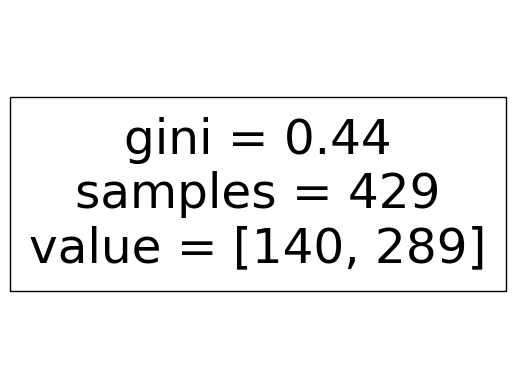

In [115]:
tree.plot_tree(best_tree) 

In [95]:
best_tree.feature_importances_

array([0.])

In [89]:
print(best_tree.get_depth())
print(best_tree.get_n_leaves())

0
1


In [91]:
y_pred_pruned = best_tree.predict(x_test[["ApplicantIncome"]])
print("Predicted Results:\n", y_pred_pruned)
recall_score(y_test,y_pred_pruned, average='macro') #weighted, micro, binary
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred_pruned)*100) 
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred_pruned))
print("Test Classification Report :\n", classification_report(y_test, y_pred_pruned))

Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']
Test Accuracy Score :  71.89189189189189
Test Confusion Matrix :
 [[  0  52]
 [  0 133]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.00      0.00      0.00        52


C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

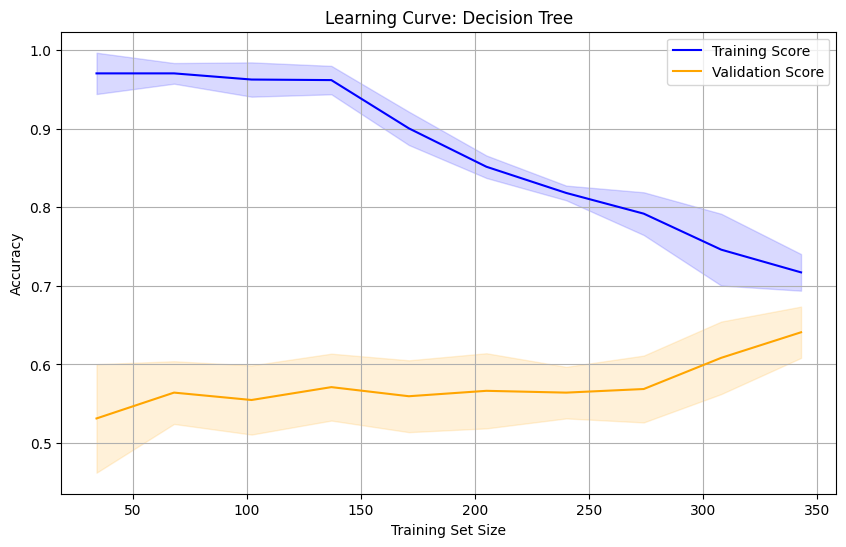

In [98]:
from sklearn.model_selection import learning_curve
# model
model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)

# learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,                 # your features
    y=y_train,                 # your target
    cv=5,                # number of folds
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=42
)

# mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Score', color='orange')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 color='blue', alpha=0.15)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 color='orange', alpha=0.15)

plt.title('Learning Curve: Decision Tree')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [99]:
# Create a mesh grid for plotting
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = y.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict over the grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap='Pastel2', alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundary")
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

# Tree

In [19]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=3, splitter='best', random_state=42)
tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


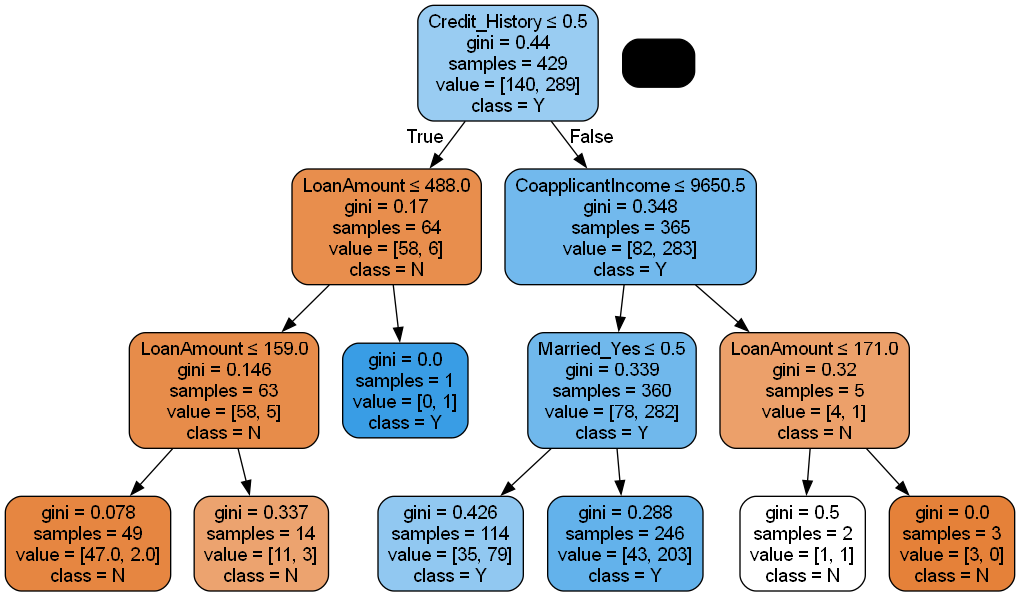

In [21]:
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names = x_train.columns ,class_names=['N','Y'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("loan_tree.png")
Image(graph.create_png())

In [150]:
# Features used 
print(tree.feature_names_in_[tree.tree_.feature[tree.tree_.feature > 0]])

# split thresholds
print(tree.tree_.threshold)



['Credit_History' 'LoanAmount' 'LoanAmount' 'CoapplicantIncome'
 'Married_Yes' 'LoanAmount']
[ 5.0000e-01  4.8800e+02  1.5900e+02 -2.0000e+00 -2.0000e+00 -2.0000e+00
  9.6505e+03  5.0000e-01 -2.0000e+00 -2.0000e+00  1.7100e+02 -2.0000e+00
 -2.0000e+00]


In [257]:
feature_index = tree.tree_.feature.tolist()
mapped = map(lambda x: "Leaf" if x==-2 else tree.feature_names_in_[x] , feature_index)
node = list(mapped)
node

['Credit_History',
 'LoanAmount',
 'LoanAmount',
 'Leaf',
 'Leaf',
 'Leaf',
 'CoapplicantIncome',
 'Married_Yes',
 'Leaf',
 'Leaf',
 'LoanAmount',
 'Leaf',
 'Leaf']

In [267]:
#prediction values at each node
df = pd.DataFrame(data=[node, tree.tree_.value[:,:,0].reshape(-1,), tree.tree_.value[:,:,1].reshape(-1,)]).T
df.rename(columns={0:"Node", 1:"Pred_N", 2:"Pred_Y"}, inplace=True)
df

,Node,Pred_N,Pred_Y
0,Credit_History,0.32634,0.67366
1,LoanAmount,0.90625,0.09375
2,LoanAmount,0.920635,0.079365
3,Leaf,0.959184,0.040816
4,Leaf,0.785714,0.214286
5,Leaf,0.0,1.0
6,CoapplicantIncome,0.224658,0.775342
7,Married_Yes,0.216667,0.783333
8,Leaf,0.307018,0.692982
9,Leaf,0.174797,0.825203


### tree calculation

In [58]:
temp = pd.concat([x_train, y_train], axis=1)
temp.shape

(429, 15)

In [59]:
temp["Credit_History"].value_counts()

Credit_History
1.0    365
0.0     64
Name: count, dtype: int64

In [61]:
temp.groupby("Credit_History")["Loan_Status"].value_counts()

Credit_History  Loan_Status
0.0             N               58
                Y                6
1.0             Y              283
                N               82
Name: count, dtype: int64

In [71]:
 (1 - (82/365)**2 - (283/365)**2)

0.34837305310564837

In [72]:
#gini impurity for credit_history < 0.5
gini = ((64/429) * (1 - (58/64)**2 - (6/64)**2)) + ((365/429) * (1 - (82/365)**2 - (283/365)**2))
print(f'gini impurity for credit_history < 0.5 = {gini}')

gini impurity for credit_history < 0.5 = 0.3217509659290481


### evaluate and predict

In [48]:
tree.feature_importances_

array([0.        , 0.0563139 , 0.04906217, 0.        , 0.84892148,
       0.        , 0.04570244, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

<Axes: ylabel='None'>

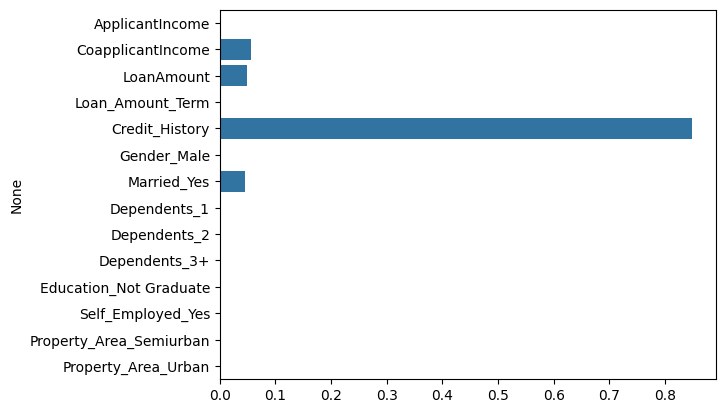

In [47]:
sns.barplot(x=tree.feature_importances_, y=x_train.columns)

In [ ]:
x_test.drop(columns=cat_df.columns, axis=1, inplace=True)
x_test = pd.concat([x_test, x_test_cat], axis=1)
x_test.shape

In [27]:
y_pred = tree.predict(x_test)
print("Predicted Results:\n", y_pred)


Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N'
 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']


In [30]:
pd.DataFrame(y_pred).value_counts()

0
Y    161
N     24
Name: count, dtype: int64

In [34]:
predictions = tree.predict_proba(x_test)

In [53]:
tree.score(x_train, y_train)

0.8041958041958042

In [49]:
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred)*100) 

Test Accuracy Score :  83.78378378378379


In [73]:
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Test Classification Report :\n", classification_report(y_test, y_pred))

Test Confusion Matrix :
 [[ 23  29]
 [  1 132]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.96      0.44      0.61        52
           Y       0.82      0.99      0.90       133

    accuracy                           0.84       185
   macro avg       0.89      0.72      0.75       185
weighted avg       0.86      0.84      0.82       185



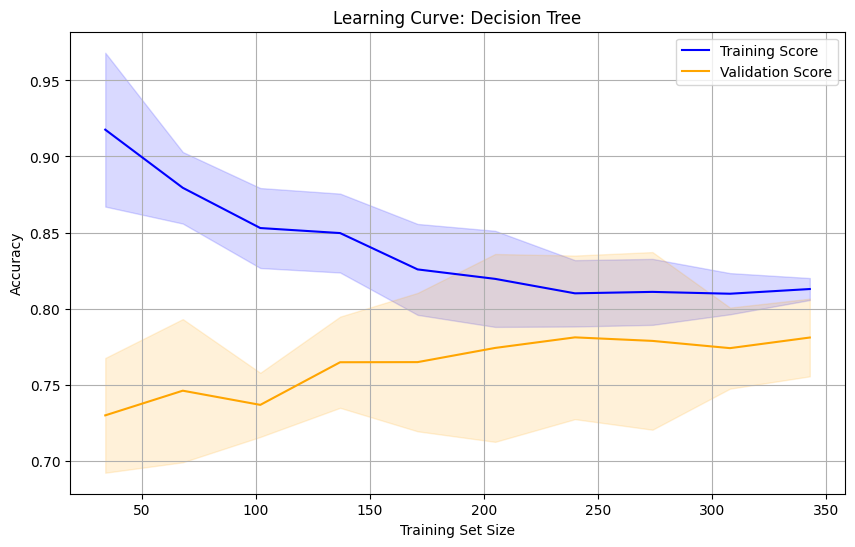

In [74]:
from sklearn.model_selection import learning_curve

# learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=tree,
    X=x_train,                 # your features
    y=y_train,                 # your target
    cv=5,                # number of folds
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=42
)

# mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Score', color='orange')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 color='blue', alpha=0.15)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 color='orange', alpha=0.15)

plt.title('Learning Curve: Decision Tree')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### PDP

In [233]:
from sklearn.inspection import partial_dependence,PartialDependenceDisplay

pdp = partial_dependence(
                    tree,       
                    features=["LoanAmount"], # column numbers of plots we want to show
                    X=x_train,            # raw predictors data.
                    feature_names=tree.feature_names_in_, # labels on graphs
                    grid_resolution=10)

pdp

{'grid_values': [array([ 55.86,  80.38, 104.9 , 129.42, 153.94, 178.46, 202.98, 227.5 ,
         252.02, 276.54])],
 'average': array([[0.66925931, 0.66925931, 0.66925931, 0.66925931, 0.66925931,
         0.68931069, 0.68931069, 0.68931069, 0.68931069, 0.68931069]])}

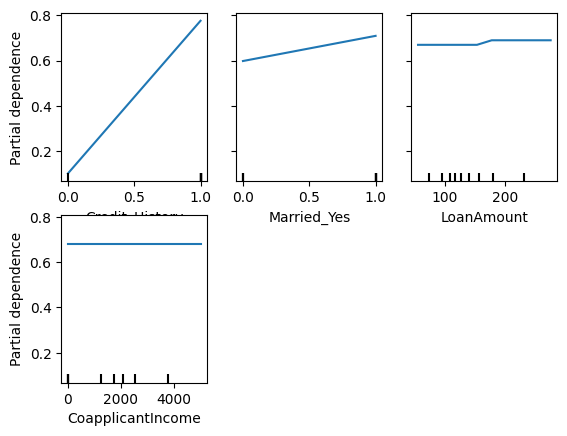

In [235]:
from sklearn.inspection import partial_dependence,PartialDependenceDisplay

deciles = {"Credit_History": np.linspace(0, 1, num=5)}

PartialDependenceDisplay.from_estimator(
    estimator=tree,
    X=x_train,
    features=["Credit_History", "Married_Yes", "LoanAmount", "CoapplicantIncome"],
    feature_names=tree.feature_names_in_,
    target=1,
    response_method='predict_proba',
    #deciles=deciles,
    grid_resolution=10
)


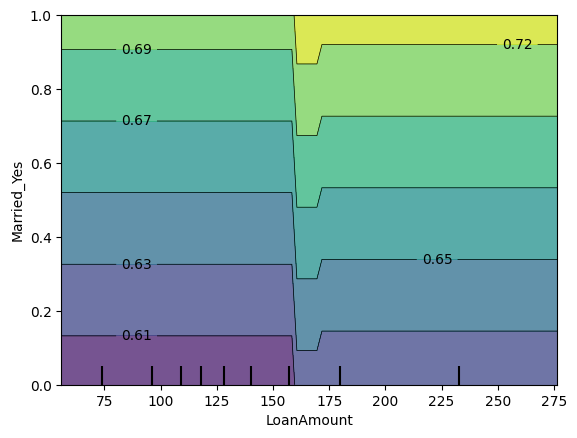

In [268]:
PartialDependenceDisplay.from_estimator(
    tree,
    x_train,
    features=[( "LoanAmount", "Married_Yes")],
    feature_names=tree.feature_names_in_,
    target=1,/````w 
)


In [ ]:
#Permutation Importance
from sklearn.inspection import permutation_importance
permutation_importance(tree, x_train, y_train)



# Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, criterion='entropy', oob_score=True) #max_features=none,log2,auto
rf.fit(x_cat, y_train)
pred_rf = rf.predict(x_test_cat)
print("RF Training score: ", rf.score(x_cat, y_train))
print("RF OOB score: ", rf.oob_score_)
print("RF Accuracy score: ", accuracy_score(y_test, pred_rf))
print(rf.feature_importances_)
sns.barplot(rf.feature_importances_, x_cat.columns)

RF Training score:  0.8018648018648019
RF OOB score:  0.7972027972027972
RF Accuracy score:  0.8324324324324325
[0.10592905 0.61363079 0.01755643 0.0579622  0.01007999 0.02651201
 0.0267366  0.02394487 0.02026456 0.08713701 0.01024649]


TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

# <a id='toc1_'></a>[Unlocking Insights with Partial Dependence Plots (PDPs): A Beginner's Tutorial](#toc0_)